# Required imports
Always run

In [1]:
import os
import glob

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

import librosa
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, GaussianNoise, Reshape
from tensorflow.keras.layers import GlobalAveragePooling1D

2026-04-18 13:30:58.807339: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 13:30:58.861282: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-18 13:31:00.196633: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


# Load dataset and extract Log Filter-Bank Energies (LFBE) features

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# Costanti del DSP  (identiche al .ino)
# ─────────────────────────────────────────────────────────────────────────────

SAMPLE_RATE         = 16_000     # Hz
FRAME_LEN_MS        = 25         # ms per slice  → 400 campioni
FRAME_STEP_MS       = 20         # ms di stride  → 320 campioni
N_MEL               = 32         # canali filterbank
FMIN                = 125.0      # Hz
FMAX                = 7_500.0    # Hz
N_SLICES            = 49         # slice nella finestra da 1 s
FFT_SIZE            = 512        # prossima pot. di 2 ≥ 400

FRAME_LEN           = FRAME_LEN_MS  * SAMPLE_RATE // 1000  # 400
FRAME_STEP          = FRAME_STEP_MS * SAMPLE_RATE // 1000  # 320

# Verifica: (16000 − 400) // 320 + 1 = 49  ✓
assert (SAMPLE_RATE - FRAME_LEN) // FRAME_STEP + 1 == N_SLICES, \
    "Mismatch numero di slices: controlla SAMPLE_RATE / FRAME_LEN / FRAME_STEP"

# Noise reduction (noise_reduction.c)
EVEN_SMOOTH         = 0.025
ODD_SMOOTH          = 0.06
MIN_SIG_REMAIN      = 0.05

# PCAN gain control (pcan_gain_control.c)
PCAN_STRENGTH       = 0.95
PCAN_OFFSET         = 80.0
PCAN_GAIN_BITS      = 21

# Log scale (log_scale.c)
LOG_SCALE_SHIFT     = 6          # shift prima del log  → divide per 64
LOG_SCALE_OUT_BITS  = 12         # bit dell'output      → moltiplica per 4096

# Quantizzazione int8  (GenerateMicroFeatures nel .ino)
#   raw uint16 ∈ [0, ~670]  →  int8 ∈ [-128, 127]
#   formula: value = (raw × 256 + 333) / 666 − 128
K_VALUE_SCALE       = 256
K_VALUE_DIV         = int(25.6 * 26.0 + 0.5)   # 666


# ─────────────────────────────────────────────────────────────────────────────
# Mel filterbank  (calcolato una sola volta all'avvio)
# ─────────────────────────────────────────────────────────────────────────────
# tf.signal.linear_to_mel_weight_matrix usa la stessa scala HTK del
# microfrontend TF Lite; restituisce shape (257, 32) già trasposta per @.
_MEL_FILTERBANK: np.ndarray = tf.signal.linear_to_mel_weight_matrix(
    num_mel_bins          = N_MEL,
    num_spectrogram_bins  = FFT_SIZE // 2 + 1,   # 257
    sample_rate           = SAMPLE_RATE,
    lower_edge_hertz      = FMIN,
    upper_edge_hertz      = FMAX,
    dtype                 = tf.float32,
).numpy()   # (257, 32)

# Finestra di Hann per i frame da 400 campioni (identica all'implementazione C)
_HANN_WINDOW: np.ndarray = np.hanning(FRAME_LEN).astype(np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# Pipeline DSP
# ─────────────────────────────────────────────────────────────────────────────

def _power_spectrum(frames: np.ndarray) -> np.ndarray:
    """
    Applica finestra di Hann, zero-padding a 512 pt, FFT e spettro di potenza.

    Parametri
    ---------
    frames : (N_SLICES, FRAME_LEN) float32
        Campioni PCM scalati in range int16 (×32768).

    Ritorna
    -------
    (N_SLICES, 257) float32 – modulo quadro dei bin FFT mono-laterali.
    """
    windowed = frames * _HANN_WINDOW                          # (49, 400)
    padded   = np.zeros((N_SLICES, FFT_SIZE), dtype=np.float32)
    padded[:, :FRAME_LEN] = windowed
    spectra  = np.abs(np.fft.rfft(padded, axis=1)) ** 2      # (49, 257)
    return spectra


def _mel_energy(spectra: np.ndarray) -> np.ndarray:
    """
    Proietta lo spettro di potenza nei canali mel.

    Parametri
    ---------
    spectra : (N_SLICES, 257) float32

    Ritorna
    -------
    (N_SLICES, N_MEL) float32 – energia per canale mel (valori assoluti grandi).
    """
    return spectra @ _MEL_FILTERBANK   # (49, 32)


def _noise_reduction_and_pcan(mel: np.ndarray) -> np.ndarray:
    """
    Noise reduction SRNN + PCAN gain control frame per frame.

    Equivale all'esecuzione in sequenza di:
      NoiseReductionApply()  →  aggiorna noise_estimate, produce segnale ripulito
      PcanGainControlApply() →  normalizza usando lo stesso noise_estimate

    Parametri
    ---------
    mel : (N_SLICES, N_MEL) float32

    Ritorna
    -------
    (N_SLICES, N_MEL) float32 – output PCAN con valori tipicamente ∈ [0, ~20].
    """
    noise_est  = np.zeros(N_MEL, dtype=np.float64)
    pcan_out   = np.zeros_like(mel)

    for i in range(N_SLICES):
        # ── Noise reduction ──────────────────────────────────────
        # Il microfrontend C usa smoothing diverso per frame pari/dispari.
        alpha = EVEN_SMOOTH if (i % 2 == 0) else ODD_SMOOTH
        noise_est = (1.0 - alpha) * noise_est + alpha * mel[i].astype(np.float64)

        sig      = mel[i].astype(np.float64)
        denoised = np.maximum(
            sig - (1.0 - MIN_SIG_REMAIN) * noise_est,
            MIN_SIG_REMAIN * sig
        )

        # ── PCAN gain control ────────────────────────────────────
        # output = denoised / (noise_est^strength + offset)
        # Lo stesso noise_estimate usato sopra, come in pcan_gain_control.c
        denom         = np.power(np.maximum(noise_est, 1e-12), PCAN_STRENGTH) + PCAN_OFFSET
        pcan_out[i]   = (denoised / denom).astype(np.float32)

    return pcan_out


def _log_scale(pcan: np.ndarray) -> np.ndarray:
    """
    Log-scale compression (log_scale.c, scale_shift=6, out_bits=12).

      output = log2(1 + x / 2^scale_shift) × 2^out_bits
             = log2(1 + x / 64) × 4096

    Produce valori uint16 tipicamente ∈ [0, ~670].

    Parametri
    ---------
    pcan : (N_SLICES, N_MEL) float32

    Ritorna
    -------
    (N_SLICES, N_MEL) float32
    """
    scale_in  = float(1 << LOG_SCALE_SHIFT)    # 64.0
    scale_out = float(1 << LOG_SCALE_OUT_BITS)  # 4096.0
    return np.log2(1.0 + np.maximum(pcan, 0.0) / scale_in) * scale_out


def _quantize_int8(log_out: np.ndarray) -> np.ndarray:
    """
    Quantizzazione uint16 → int8 identica a GenerateMicroFeatures() nel .ino.

      value = (raw × 256 + 333) / 666 − 128
      clamp a [-128, 127]

    Parametri
    ---------
    log_out : (N_SLICES, N_MEL) float32  – valori raw ∈ [0, ~670]

    Ritorna
    -------
    (N_SLICES, N_MEL) int8
    """
    raw   = log_out.astype(np.int64)
    value = (raw * K_VALUE_SCALE + K_VALUE_DIV // 2) // K_VALUE_DIV - 128
    return np.clip(value, -128, 127).astype(np.int8)


def extract_features(wav_path: str) -> np.ndarray:
    """
    Carica un file WAV e restituisce il tensore di feature int8.

    L'output è identico al buffer g_feature_data[kFeatureElementCount]
    dell'Arduino (49 × 32 = 1568 byte).

    Parametri
    ---------
    wav_path : str – percorso al file .wav (qualsiasi sample rate / canali).

    Ritorna
    -------
    (49, 32) int8 – spectrogram quantizzato.
    """
    # ── Carica e normalizza l'audio ───────────────────────────────────────────
    # librosa resampla a 16 kHz e converte in mono automaticamente.
    audio, _ = librosa.load(wav_path, sr=SAMPLE_RATE, mono=True, duration=1.0)

    # Padding / trimming per garantire esattamente 1 s = 16000 campioni
    target_len = SAMPLE_RATE
    if len(audio) < target_len:
        audio = np.pad(audio, (0, target_len - len(audio)))
    else:
        audio = audio[:target_len]

    # Scala a range int16 come i campioni PDM dell'Arduino
    audio = (audio * 32768.0).astype(np.float32)

    # ── Framing ───────────────────────────────────────────────────────────────
    # sliding_window_view + stride manuale = equivalente di librosa.util.frame
    frames = np.lib.stride_tricks.sliding_window_view(audio, FRAME_LEN)[::FRAME_STEP]
    frames = frames[:N_SLICES].copy()   # (49, 400)

    # ── DSP pipeline ─────────────────────────────────────────────────────────
    spectra  = _power_spectrum(frames)           # (49, 257) float32
    mel      = _mel_energy(spectra)              # (49, 32)  float32
    pcan     = _noise_reduction_and_pcan(mel)    # (49, 32)  float32
    log_out  = _log_scale(pcan)                  # (49, 32)  float32
    features = _quantize_int8(log_out)           # (49, 32)  int8

    return features


# ─────────────────────────────────────────────────────────────────────────────
# Caricamento dataset (struttura identica al codice nel tuo notebook)
# ─────────────────────────────────────────────────────────────────────────────

def load_dataset(folder: str):
    """
    Scansiona *folder* per file .wav.
    Il label è la parte del filename prima del primo punto.

    Ritorna
    -------
    file_paths : list[str]
    labels     : list[str]
    """
    file_paths, labels = [], []
    for file in glob.glob(os.path.join(folder, "*.wav")):
        label = os.path.basename(file).split(".")[0]
        file_paths.append(file)
        labels.append(label)
    return file_paths, labels


def process_split(file_paths: list, split_name: str) -> np.ndarray:
    """
    Estrae le feature da tutti i file di un split con barra di avanzamento.

    Parametri
    ---------
    file_paths : list[str]
    split_name : str – usato solo per il titolo della progress bar

    Ritorna
    -------
    (N, 49, 32) int8
    """
    features = []
    errors   = []

    for path in tqdm(file_paths, desc=f"Extracting {split_name}", unit="file"):
        try:
            features.append(extract_features(path))
        except Exception as exc:
            errors.append((path, str(exc)))
            # Inserisce un tensore di zeri per non rompere l'allineamento con y
            features.append(np.zeros((N_SLICES, N_MEL), dtype=np.int8))

    if errors:
        print(f"\n[WARN] {len(errors)} file non processati in {split_name}:")
        for p, e in errors[:5]:
            print(f"  {p}: {e}")
        if len(errors) > 5:
            print(f"  … e altri {len(errors) - 5}")

    return np.stack(features, axis=0)   # (N, 49, 32)


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────
dataset_path = "dataset"
train_dir    = os.path.join(dataset_path, "training")
test_dir     = os.path.join(dataset_path, "testing")

# ── Carica percorsi e label testuali ─────────────────────────────────────
X_train_paths, y_train_str = load_dataset(train_dir)
X_test_paths,  y_test_str  = load_dataset(test_dir)

print(f"Training samples : {len(X_train_paths)}")
print(f"Testing samples  : {len(X_test_paths)}")

# ── StringLookup → one-hot (identico al notebook originale) ──────────────
lookup = tf.keras.layers.StringLookup(
    output_mode    = "one_hot",
    num_oov_indices = 0,
)
lookup.adapt(y_train_str)

y_train = lookup(y_train_str)   # (N_train, num_classes) int64
y_test  = lookup(y_test_str)    # (N_test,  num_classes) int64

labels      = lookup.get_vocabulary()
num_classes = len(labels)
print(f"Classi ({num_classes}): {labels}")

# ── Estrazione feature ────────────────────────────────────────────────────
X_train = process_split(X_train_paths, "train")   # (N_train, 49, 32) int8
X_test  = process_split(X_test_paths,  "test")    # (N_test,  49, 32) int8

print(f"\nX_train shape : {X_train.shape}  dtype={X_train.dtype}")
print(f"X_test  shape : {X_test.shape}   dtype={X_test.dtype}")
print(f"y_train shape : {y_train.shape}  dtype={y_train.dtype}")
print(f"y_test  shape : {y_test.shape}   dtype={y_test.dtype}")

# ── Salva su disco ────────────────────────────────────────────────────────
os.makedirs("features", exist_ok=True)
np.save("features/X_train.npy", X_train)
np.save("features/X_test.npy",  X_test)
np.save("features/y_train.npy", y_train.numpy())
np.save("features/y_test.npy",  y_test.numpy())
np.save("features/labels.npy",  np.array(labels))

print("\nFeature salvate in features/")
print("  X_train.npy  X_test.npy  y_train.npy  y_test.npy  labels.npy")

# ─────────────────────────────────────────────────────────────────────────
# Costruzione tf.data.Dataset pronti per il training
# ─────────────────────────────────────────────────────────────────────────

BATCH_SIZE  = 32
AUTOTUNE    = tf.data.AUTOTUNE

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train,
    y_train.numpy(),   # sklearn vuole numpy
    test_size=0.2,     # 20% validation
    stratify=y_train.numpy(),  # mantiene distribuzione classi
    random_state=42
)

# Converti y in tensor
y_train_final = tf.convert_to_tensor(y_train_final)
y_val         = tf.convert_to_tensor(y_val)

# Converti X in float32 (range approssimativo [-1, 1] dopo rescaling)
# Il modello riceve (49, 32, 1) – aggiunta dim canale per Conv2D.
def make_dataset(X: np.ndarray, y: tf.Tensor, shuffle: bool) -> tf.data.Dataset:
    # float32 normalizzato in [-1, 1] per facilitare il training
    X_f = (X.astype(np.float32) / 128.0).reshape(len(X), -1)  # (N, 1568)
    ds  = tf.data.Dataset.from_tensor_slices((X_f, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), reshuffle_each_iteration=True)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = make_dataset(X_train_final, y_train_final, shuffle=True)
val_ds   = make_dataset(X_val,   y_val,   shuffle=False)
test_ds  = make_dataset(X_test,  y_test,  shuffle=False)

print("\ntrain_ds:", train_ds)
print("val_ds  :", val_ds)
print("test_ds :", test_ds)

Training samples : 2615
Testing samples  : 641
Classi (5): ['noise', 'unknown', 'heynano', 'on', 'off']


E0000 00:00:1776511861.985715    8351 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776511861.998310    8351 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Extracting train:   0%|          | 0/2615 [00:00<?, ?file/s]

Extracting test:   0%|          | 0/641 [00:00<?, ?file/s]


X_train shape : (2615, 49, 32)  dtype=int8
X_test  shape : (641, 49, 32)   dtype=int8
y_train shape : (2615, 5)  dtype=<dtype: 'int64'>
y_test  shape : (641, 5)   dtype=<dtype: 'int64'>

Feature salvate in features/
  X_train.npy  X_test.npy  y_train.npy  y_test.npy  labels.npy

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1568), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int64, name=None))>
val_ds  : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1568), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int64, name=None))>
test_ds : <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 1568), dtype=tf.float32, name=None), TensorSpec(shape=(None, 5), dtype=tf.int64, name=None))>


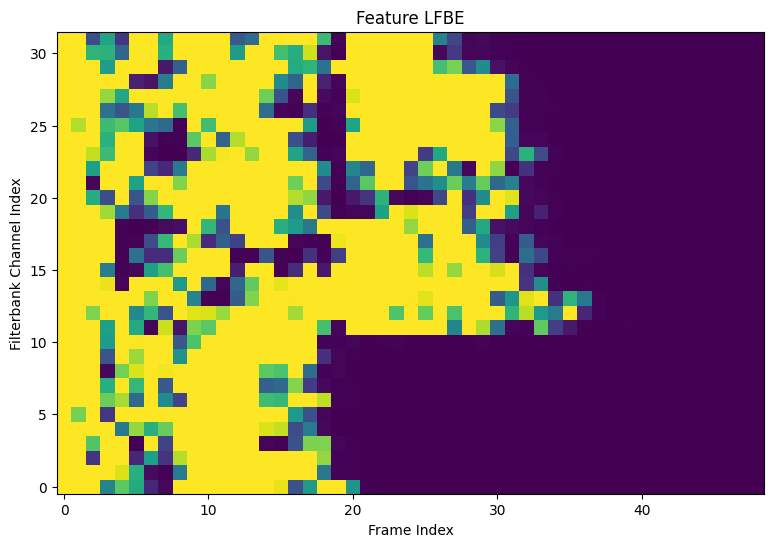

In [3]:
# Plot MFCC
plt.figure(figsize=(10,6))
plt.imshow(X_train[0].T, cmap='viridis', origin='lower')
plt.title("Feature LFBE")
plt.xlabel("Frame Index")
plt.ylabel("Filterbank Channel Index")
plt.show()

# Train model

In [4]:
# train model
model = Sequential()
model.add(tf.keras.Input(shape=(1568,)))
model.add(GaussianNoise(0.1))
model.add(Reshape((49, 32)))
model.add(Conv1D(8, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.25))
model.add(Conv1D(16, kernel_size=5, padding='same', activation='relu'))
model.add(MaxPooling1D(pool_size=2, strides=2, padding='same'))
model.add(Dropout(0.25))
model.add(GlobalAveragePooling1D())
model.add(Dense(num_classes, activation='softmax'))

model.summary()

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gaussian_noise (GaussianNoise)  │ (None, 1568)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 49, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 49, 8)          │         1,288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25, 8)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 25, 16)         │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 13, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │            85 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,029 (7.93 KB)

 Trainable params: 2,029 (7.93 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Epoch 1/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.2749 - loss: 1.5796 - val_accuracy: 0.4302 - val_loss: 1.4908
Epoch 2/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3824 - loss: 1.4494 - val_accuracy: 0.5621 - val_loss: 1.3062
Epoch 3/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5167 - loss: 1.2802 - val_accuracy: 0.6826 - val_loss: 1.1117
Epoch 4/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5727 - loss: 1.1264 - val_accuracy: 0.7189 - val_loss: 0.9653
Epoch 5/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6200 - loss: 1.0159 - val_accuracy: 0.7553 - val_loss: 0.8373
Epoch 6/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6429 - loss: 0.9301 - val_accuracy: 0.7438 - val_loss: 0.7773
Epoch 7/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6597 - loss: 0.8765 - val_accuracy: 0.7629 - val_loss: 0.7197
Epoch 8/100
66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6888 - loss: 0.8418 - val_accuracy: 0.7801 - v

In [6]:
# Valutazione
test_loss, test_acc = model.evaluate(test_ds)

print("Test accuracy:", test_acc)

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8346 - loss: 0.4980 
Test accuracy: 0.8346334099769592


In [7]:
# Save model
model.save("models/best.keras")

# Quantization

In [ ]:
# Load model
# model = tf.keras.models.load_model("models/best.keras")

In [8]:
# Convert to TFLite full int8
def representative_dataset():
    idx = np.random.choice(len(X_train), 300, replace=False)
    for i in idx:
        data = X_train[i].astype(np.float32)
        data = np.expand_dims(data, axis=0)
        yield [data]

converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

converter.representative_dataset = representative_dataset

converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]

converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_quant_model = converter.convert()

save_path = "models/best.tflite"

with open(save_path, "wb") as f:
    f.write(tflite_quant_model)

print("Modello salvato in:", save_path)

INFO:tensorflow:Assets written to: /tmp/tmpr43gj9h1/assets


INFO:tensorflow:Assets written to: /tmp/tmpr43gj9h1/assets


Saved artifact at '/tmp/tmpr43gj9h1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1568), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  138916536899664: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916536900240: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916536901968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916536902544: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916536902736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138916536902928: TensorSpec(shape=(), dtype=tf.resource, name=None)


/home/nicola/KeywordSpotting/.venv/lib/python3.12/site-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Modello salvato in: models/best.tflite


W0000 00:00:1776511932.175697    8351 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1776511932.175716    8351 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
2026-04-18 13:32:12.176056: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpr43gj9h1
2026-04-18 13:32:12.176548: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2026-04-18 13:32:12.176553: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmpr43gj9h1
I0000 00:00:1776511932.180721    8351 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled
2026-04-18 13:32:12.181700: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2026-04-18 13:32:12.213079: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmpr43gj9h1
2026-04-18 13:32:12.224167: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 

In [9]:
# Controllo dimensione del modello quantizzato
size_kb = os.path.getsize("models/best.tflite") / 1024
print("Dimensione modello:", round(size_kb,2), "KB")

Dimensione modello: 9.31 KB


## Convert the tflite model to a C array
(we use git bash on windows, so we can use xxd command)

```bash
cd models/

xxd -i best.tflite > model_data.cc
```

next add to model_data.cc:
```c
#include "model_data.h"
```
and at the start of the array:
```c
alignas(16) const
```
to the array definition and length  
finally rename the array to `g_model_data` and length to `g_model_data_len`

## Arduino deploy
Inside Arduino libraries folder on your system
```bash
git clone https://github.com/tensorflow/tflite-micro-arduino-examples Arduino_TensorFlowLite
```